In [ ]:
# Install Kagglehub

!pip install -q kagglehub

In [ ]:
# Import Libraries

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Download the Kaggle Dataset

dataset_path = kagglehub.dataset_download(
    "alexteboul/diabetes-health-indicators-dataset"
)

print("Dataset downloaded to:")
print(dataset_path)

Using Colab cache for faster access to the 'diabetes-health-indicators-dataset' dataset.
Dataset downloaded to:
/kaggle/input/diabetes-health-indicators-dataset


In [ ]:
# Check all downloaded files

for root, directories, files in os.walk(dataset_path):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/diabetes-health-indicators-dataset/diabetes_binary_5050split_health_indicators_BRFSS2015.csv
/kaggle/input/diabetes-health-indicators-dataset/diabetes_binary_health_indicators_BRFSS2015.csv
/kaggle/input/diabetes-health-indicators-dataset/diabetes_012_health_indicators_BRFSS2015.csv


In [ ]:
# Locate the correct csv file

csv_filename = "diabetes_binary_5050split_health_indicators_BRFSS2015.csv"

csv_path = None

for root, directories, files in os.walk(dataset_path):
    if csv_filename in files:
        csv_path = os.path.join(root, csv_filename)
        break

if csv_path is None:
    raise FileNotFoundError(
        f"{csv_filename} was not found inside the downloaded dataset."
    )

print("Correct dataset found:")
print(csv_path)

Correct dataset found:
/kaggle/input/diabetes-health-indicators-dataset/diabetes_binary_5050split_health_indicators_BRFSS2015.csv


In [ ]:
# Load the dataset

df = pd.read_csv(csv_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (70692, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [ ]:
# Inspect the dataset

print("First five rows:")
display(df.head())

print("\nLast five rows:")
display(df.tail())

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

First five rows:


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0



Last five rows:


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
70687,1.0,0.0,1.0,1.0,37.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,0.0,0.0,6.0,4.0,1.0
70688,1.0,0.0,1.0,1.0,29.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,2.0,0.0,0.0,1.0,1.0,10.0,3.0,6.0
70689,1.0,1.0,1.0,1.0,25.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,5.0,15.0,0.0,1.0,0.0,13.0,6.0,4.0
70690,1.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
70691,1.0,1.0,1.0,1.0,25.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,9.0,6.0,2.0



Column names:
['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits  

In [ ]:
# Describe the dataset

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,70692.0,0.500000,0.500004,0.0,0.0,0.5,1.0,1.0
HighBP,70692.0,0.563458,0.495960,0.0,0.0,1.0,1.0,1.0
HighChol,70692.0,0.525703,0.499342,0.0,0.0,1.0,1.0,1.0
CholCheck,70692.0,0.975259,0.155336,0.0,1.0,1.0,1.0,1.0
BMI,70692.0,29.856985,7.113954,12.0,25.0,29.0,33.0,98.0
Smoker,70692.0,0.475273,0.499392,0.0,0.0,0.0,1.0,1.0
Stroke,70692.0,0.062171,0.241468,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,70692.0,0.147810,0.354914,0.0,0.0,0.0,0.0,1.0
PhysActivity,70692.0,0.703036,0.456924,0.0,0.0,1.0,1.0,1.0
Fruits,70692.0,0.611795,0.487345,0.0,0.0,1.0,1.0,1.0


In [ ]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
display(missing_values.to_frame(name="Missing Values"))

print("\nTotal missing values:", missing_values.sum())

Missing values in each column:


,Missing Values
Diabetes_binary,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0



Total missing values: 0


In [ ]:
# Check duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)
print("Duplicates are not removed because the paper did not report removing them.")

Number of duplicate rows: 1635
Duplicates are not removed because the paper did not report removing them.


In [ ]:
# Examine target variable (disease/no-disease)

target_column = "Diabetes_binary"

print("Target value counts:")
print(df[target_column].value_counts())

print("\nTarget percentages:")
print(df[target_column].value_counts(normalize=True) * 100)

Target value counts:
Diabetes_binary
0.0    35346
1.0    35346
Name: count, dtype: int64

Target percentages:
Diabetes_binary
0.0    50.0
1.0    50.0
Name: proportion, dtype: float64


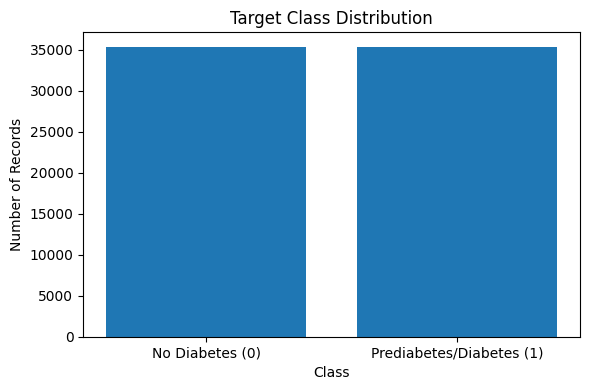

In [ ]:
# Plot the target distribution

target_counts = df[target_column].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(
    ["No Diabetes (0)", "Prediabetes/Diabetes (1)"],
    target_counts.values
)

plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

In [ ]:
# Seperate features and targets

X = df.drop(columns=[target_column])
y = df[target_column].astype(int)

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nNumber of input features:", X.shape[1])
print("\nFeature names:")
print(X.columns.tolist())

Feature matrix shape: (70692, 21)
Target vector shape: (70692,)

Number of input features: 21

Feature names:
['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


In [ ]:
# Create the 80/20 training test split

RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (56553, 21)
Testing features shape: (14139, 21)
Training target shape: (56553,)
Testing target shape: (14139,)


In [ ]:
# Check class distribution after splitting

print("Training target distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting target distribution:")
print(y_test.value_counts().sort_index())

Training target distribution:
Diabetes_binary
0    28256
1    28297
Name: count, dtype: int64

Testing target distribution:
Diabetes_binary
0    7090
1    7049
Name: count, dtype: int64


In [ ]:
# Evaluation function

experiment_results = []


def evaluate_model(
    model,
    model_name,
    X_train_data,
    X_test_data,
    y_train_data,
    y_test_data,
    show_confusion_matrix=True,
    show_report=True
):
    """
    Train and evaluate a classification model.

    The paper reports the positive-class precision, recall and F1-score,
    so average='binary' is used.
    """

    model.fit(X_train_data, y_train_data)

    train_predictions = model.predict(X_train_data)
    test_predictions = model.predict(X_test_data)

    train_accuracy = accuracy_score(y_train_data, train_predictions)
    test_accuracy = accuracy_score(y_test_data, test_predictions)

    precision = precision_score(
        y_test_data,
        test_predictions,
        pos_label=1,
        zero_division=0
    )

    recall = recall_score(
        y_test_data,
        test_predictions,
        pos_label=1,
        zero_division=0
    )

    f1 = f1_score(
        y_test_data,
        test_predictions,
        pos_label=1,
        zero_division=0
    )

    overfitting_gap = train_accuracy - test_accuracy

    cm = confusion_matrix(y_test_data, test_predictions)

    result = {
        "Model": model_name,
        "Feature Count": X_train_data.shape[1],
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Precision Class 1": precision,
        "Recall Class 1": recall,
        "F1 Class 1": f1,
        "Overfitting Gap": overfitting_gap,
        "TN": cm[0, 0],
        "FP": cm[0, 1],
        "FN": cm[1, 0],
        "TP": cm[1, 1]
    }

    experiment_results.append(result)

    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print(f"Number of features: {X_train_data.shape[1]}")
    print(f"Training accuracy:  {train_accuracy:.6f}")
    print(f"Testing accuracy:   {test_accuracy:.6f}")
    print(f"Precision class 1:  {precision:.6f}")
    print(f"Recall class 1:     {recall:.6f}")
    print(f"F1-score class 1:   {f1:.6f}")
    print(f"Overfitting gap:    {overfitting_gap:.6f}")

    print("\nConfusion matrix values:")
    print(f"True Negatives:  {cm[0, 0]}")
    print(f"False Positives: {cm[0, 1]}")
    print(f"False Negatives: {cm[1, 0]}")
    print(f"True Positives:  {cm[1, 1]}")

    if show_report:
        print("\nClassification report:")
        print(
            classification_report(
                y_test_data,
                test_predictions,
                digits=6,
                zero_division=0
            )
        )

    if show_confusion_matrix:
        ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["No Diabetes", "Diabetes"]
        ).plot(values_format="d")

        plt.title(f"Confusion Matrix: {model_name}")
        plt.tight_layout()
        plt.show()

    return model, test_predictions, result

Default Random Forest
Number of features: 21
Training accuracy:  0.995102
Testing accuracy:   0.737110
Precision class 1:  0.717210
Recall class 1:     0.780394
F1-score class 1:   0.747469
Overfitting gap:    0.257992

Confusion matrix values:
True Negatives:  4921
False Positives: 2169
False Negatives: 1548
True Positives:  5501

Classification report:
              precision    recall  f1-score   support

           0   0.760705  0.694076  0.725865      7090
           1   0.717210  0.780394  0.747469      7049

    accuracy                       0.737110     14139
   macro avg   0.738957  0.737235  0.736667     14139
weighted avg   0.739020  0.737110  0.736636     14139



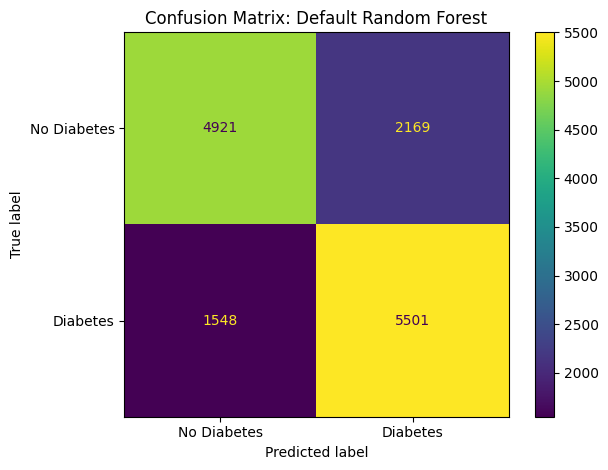

In [ ]:
# Training the baseline model

default_rf = RandomForestClassifier(
    random_state=RANDOM_STATE
)

default_rf, default_predictions, default_result = evaluate_model(
    model=default_rf,
    model_name="Default Random Forest",
    X_train_data=X_train,
    X_test_data=X_test,
    y_train_data=y_train,
    y_test_data=y_test
)

In [ ]:
# Feature importance before tuning
# This uses the default Random Forest model.

default_feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": default_rf.feature_importances_
})

default_feature_importance_df = (
    default_feature_importance_df
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

default_feature_importance_df["Rank"] = (
    np.arange(1, len(default_feature_importance_df) + 1)
)

default_feature_importance_df = default_feature_importance_df[
    ["Rank", "Feature", "Importance"]
]

print("Feature importance before tuning:")
display(default_feature_importance_df)

Feature importance before tuning:


,Rank,Feature,Importance
0,1,BMI,0.169663
1,2,Age,0.126936
2,3,GenHlth,0.107056
3,4,Income,0.084338
4,5,HighBP,0.074710
5,6,PhysHlth,0.068291
6,7,Education,0.058364
7,8,MentHlth,0.052193
8,9,HighChol,0.040868
9,10,Smoker,0.028711


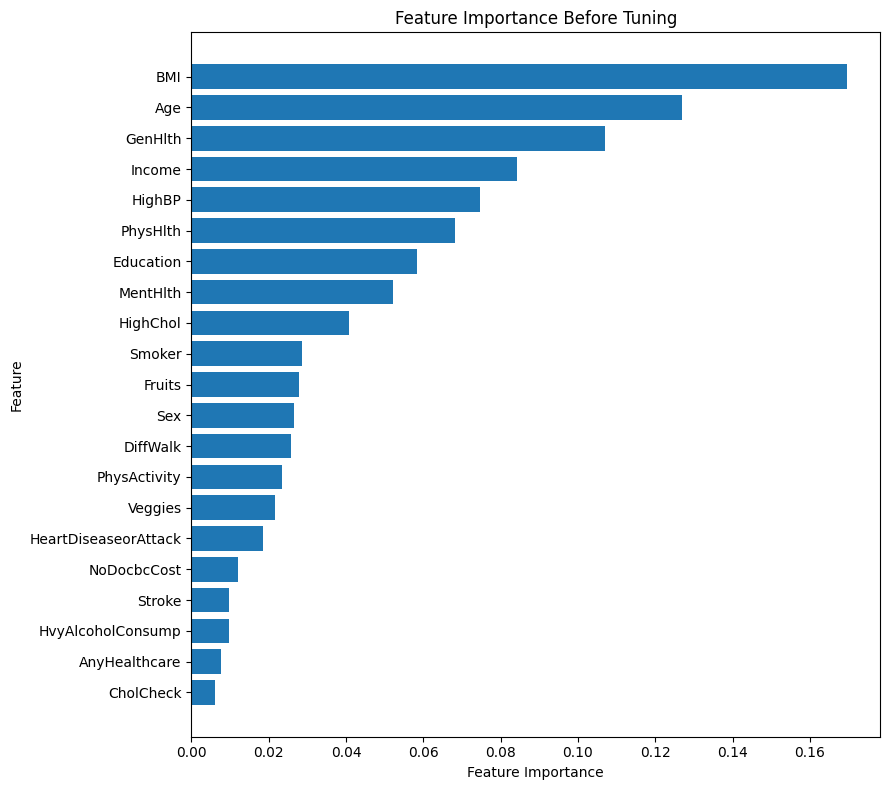

In [ ]:
# Plot feature importance before tuning

default_plot_data = default_feature_importance_df.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(9, 8))

plt.barh(
    default_plot_data["Feature"],
    default_plot_data["Importance"]
)

plt.title("Feature Importance Before Tuning")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

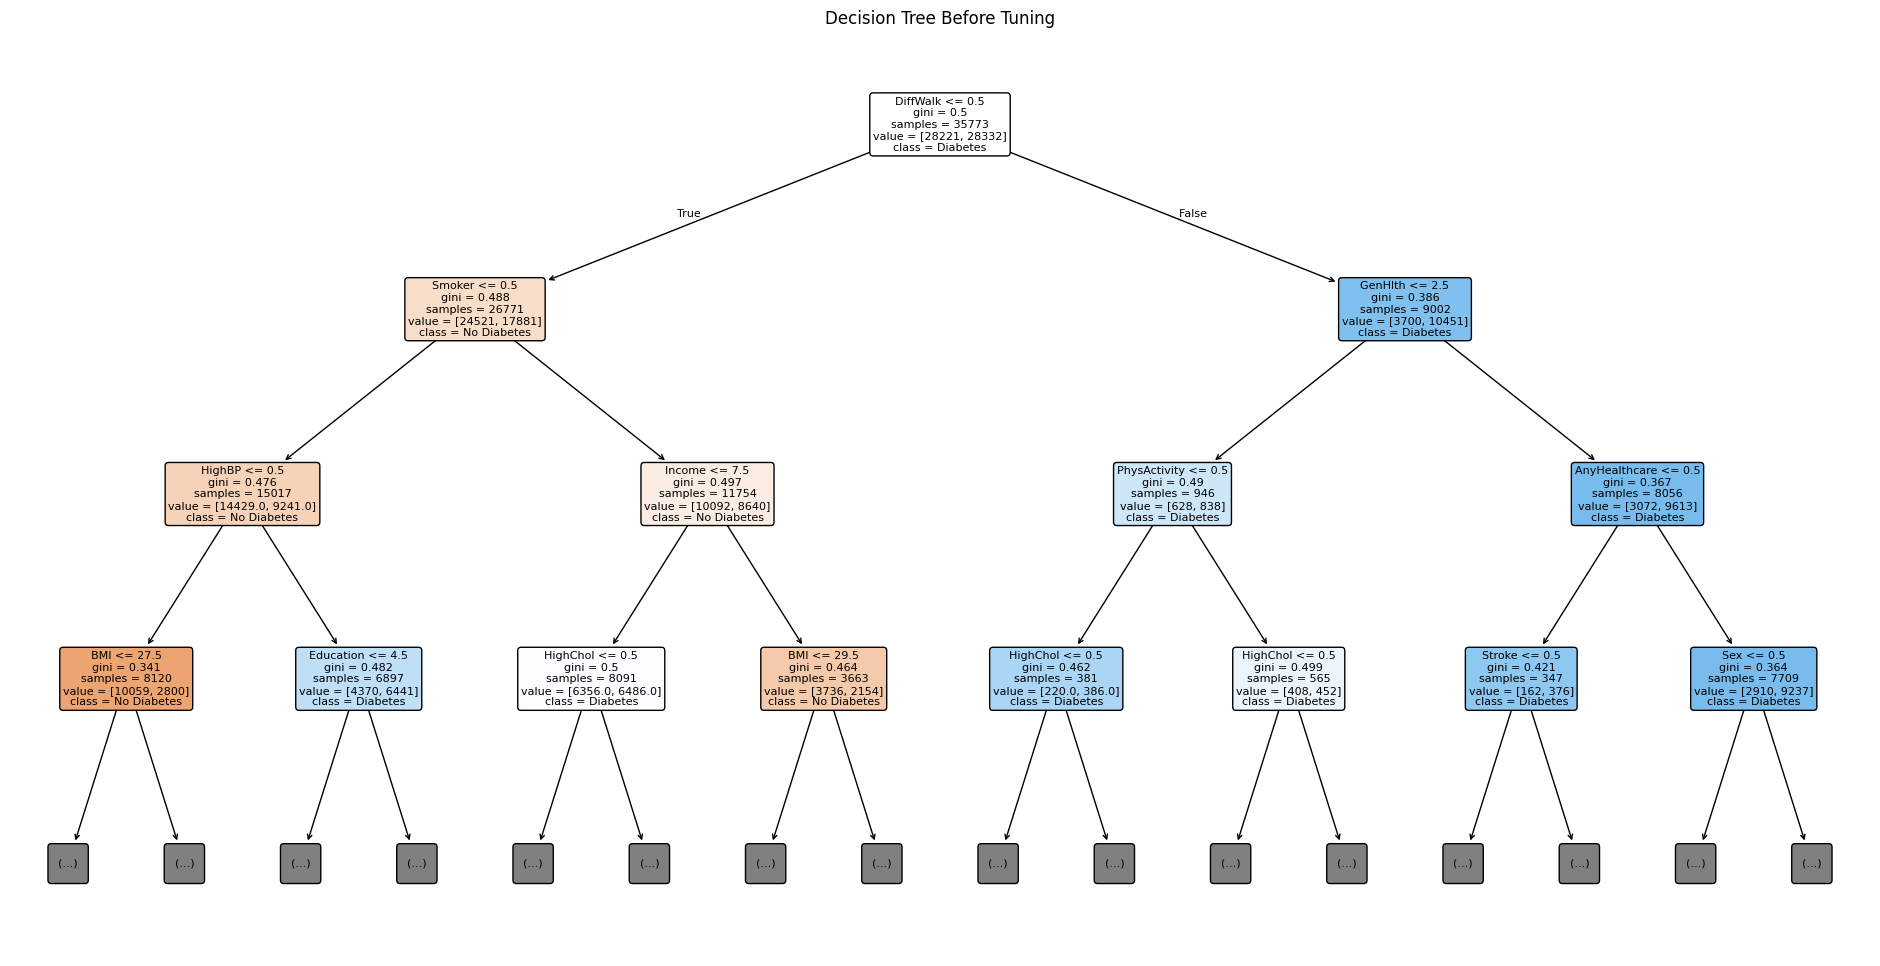

In [ ]:
# Visualize one decision tree from the default Random Forest

default_tree = default_rf.estimators_[0]

plt.figure(figsize=(24,12))

plot_tree(
    default_tree,
    feature_names=X.columns,
    class_names=["No Diabetes","Diabetes"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree Before Tuning")
plt.show()

Random Forest + Balanced Weight
Number of features: 21
Training accuracy:  0.995102
Testing accuracy:   0.738383
Precision class 1:  0.719298
Recall class 1:     0.779401
F1-score class 1:   0.748145
Overfitting gap:    0.256719

Confusion matrix values:
True Negatives:  4946
False Positives: 2144
False Negatives: 1555
True Positives:  5494

Classification report:
              precision    recall  f1-score   support

           0   0.760806  0.697602  0.727835      7090
           1   0.719298  0.779401  0.748145      7049

    accuracy                       0.738383     14139
   macro avg   0.740052  0.738502  0.737990     14139
weighted avg   0.740112  0.738383  0.737960     14139



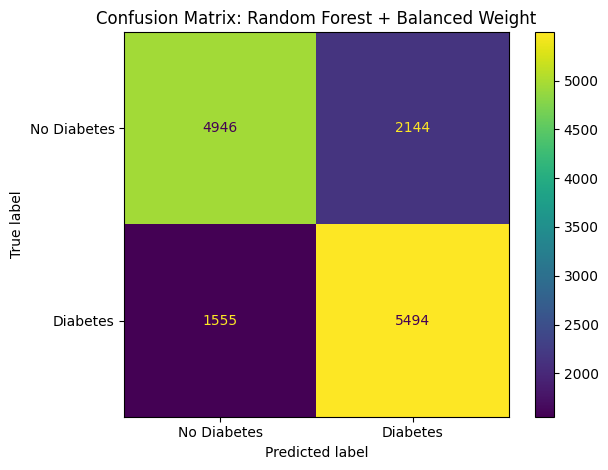

In [ ]:
# Train with balanced class weights

balanced_rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=RANDOM_STATE
)

balanced_rf, balanced_predictions, balanced_result = evaluate_model(
    model=balanced_rf,
    model_name="Random Forest + Balanced Weight",
    X_train_data=X_train,
    X_test_data=X_test,
    y_train_data=y_train,
    y_test_data=y_test
)

Tuned Random Forest - All 21 Features
Number of features: 21
Training accuracy:  0.771100
Testing accuracy:   0.752175
Precision class 1:  0.730584
Recall class 1:     0.796709
F1-score class 1:   0.762215
Overfitting gap:    0.018925

Confusion matrix values:
True Negatives:  5019
False Positives: 2071
False Negatives: 1433
True Positives:  5616

Classification report:
              precision    recall  f1-score   support

           0   0.777898  0.707898  0.741249      7090
           1   0.730584  0.796709  0.762215      7049

    accuracy                       0.752175     14139
   macro avg   0.754241  0.752304  0.751732     14139
weighted avg   0.754310  0.752175  0.751702     14139



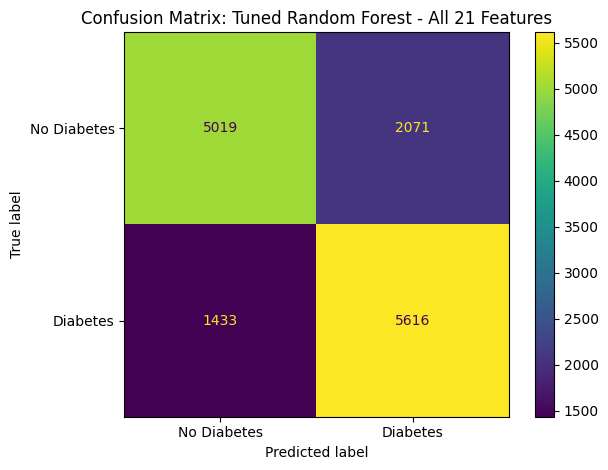

In [ ]:
# Tuned random forest

tuned_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    random_state=RANDOM_STATE
)

tuned_rf, tuned_predictions, tuned_result = evaluate_model(
    model=tuned_rf,
    model_name="Tuned Random Forest - All 21 Features",
    X_train_data=X_train,
    X_test_data=X_test,
    y_train_data=y_train,
    y_test_data=y_test
)

In [ ]:
# Extract feature importance

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tuned_rf.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance_df["Rank"] = (
    np.arange(1, len(feature_importance_df) + 1)
)

feature_importance_df = feature_importance_df[
    ["Rank", "Feature", "Importance"]
]

display(feature_importance_df)

,Rank,Feature,Importance
0,1,GenHlth,0.230866
1,2,HighBP,0.212756
2,3,BMI,0.133385
3,4,Age,0.099191
4,5,HighChol,0.094726
5,6,DiffWalk,0.051484
6,7,Income,0.034561
7,8,HeartDiseaseorAttack,0.028530
8,9,PhysHlth,0.027590
9,10,Education,0.014359


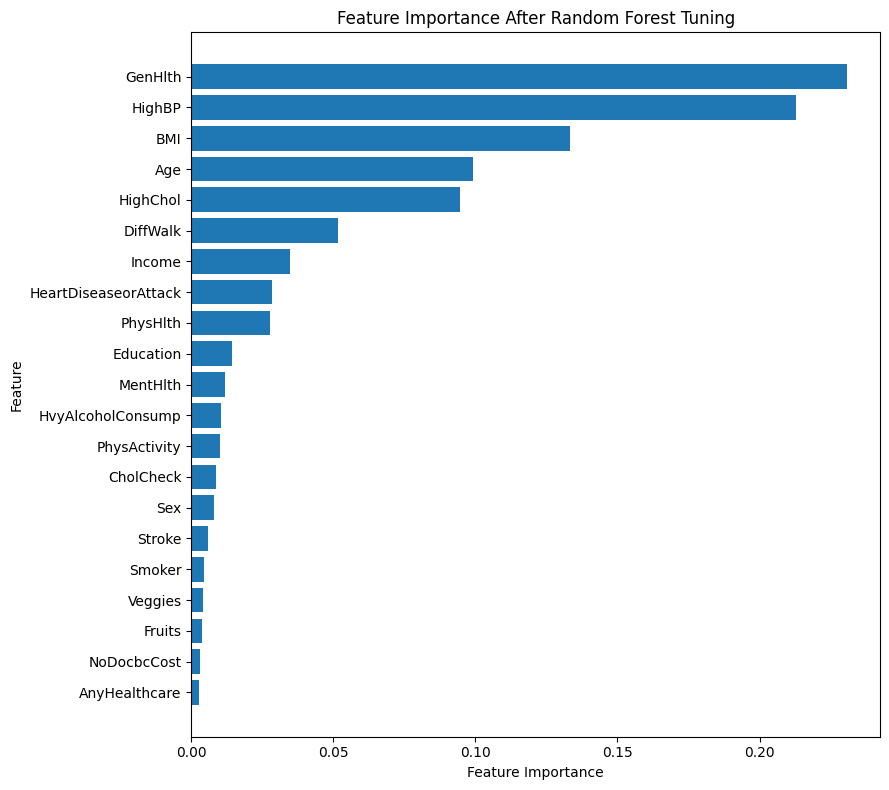

In [ ]:
# Feature importance after tuning

plot_data = feature_importance_df.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(9, 8))

plt.barh(
    plot_data["Feature"],
    plot_data["Importance"]
)

plt.title("Feature Importance After Random Forest Tuning")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
# Display top features

top_16_features = feature_importance_df.head(16)["Feature"].tolist()
top_12_features = feature_importance_df.head(12)["Feature"].tolist()
top_8_features = feature_importance_df.head(8)["Feature"].tolist()
top_4_features = feature_importance_df.head(4)["Feature"].tolist()

print("Top 16 features:")
print(top_16_features)

print("\nTop 12 features:")
print(top_12_features)

print("\nTop 8 features:")
print(top_8_features)

print("\nTop 4 features:")
print(top_4_features)

Top 16 features:
['GenHlth', 'HighBP', 'BMI', 'Age', 'HighChol', 'DiffWalk', 'Income', 'HeartDiseaseorAttack', 'PhysHlth', 'Education', 'MentHlth', 'HvyAlcoholConsump', 'PhysActivity', 'CholCheck', 'Sex', 'Stroke']

Top 12 features:
['GenHlth', 'HighBP', 'BMI', 'Age', 'HighChol', 'DiffWalk', 'Income', 'HeartDiseaseorAttack', 'PhysHlth', 'Education', 'MentHlth', 'HvyAlcoholConsump']

Top 8 features:
['GenHlth', 'HighBP', 'BMI', 'Age', 'HighChol', 'DiffWalk', 'Income', 'HeartDiseaseorAttack']

Top 4 features:
['GenHlth', 'HighBP', 'BMI', 'Age']


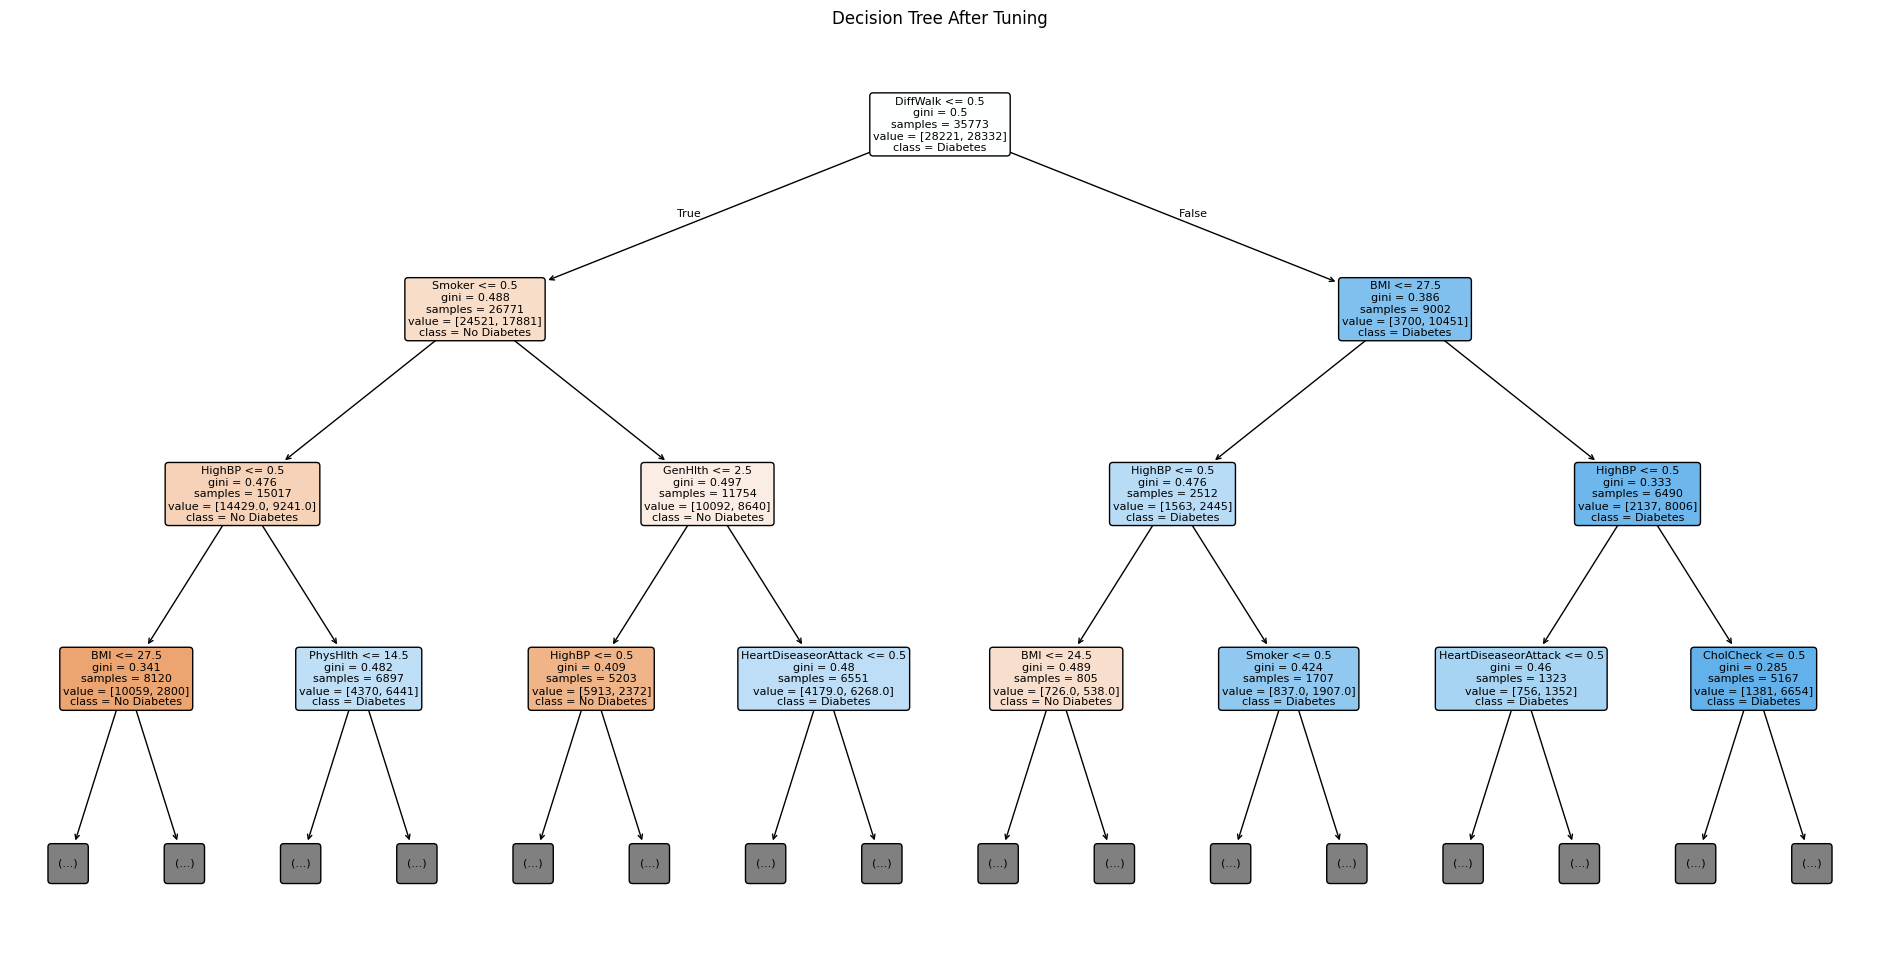

In [ ]:
# Visualize one decision tree from the tuned Random Forest

tuned_tree = tuned_rf.estimators_[0]

plt.figure(figsize=(24,12))

plot_tree(
    tuned_tree,
    feature_names=X.columns,
    class_names=["No Diabetes","Diabetes"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree After Tuning")
plt.show()

In [ ]:
# Function for reduced-feature experiments

def train_reduced_feature_model(feature_list, model_name):
    """
    Retrain the tuned Random Forest using a selected subset of features.
    """

    X_train_reduced = X_train[feature_list]
    X_test_reduced = X_test[feature_list]

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=10,
        random_state=RANDOM_STATE
    )

    trained_model, predictions, result = evaluate_model(
        model=model,
        model_name=model_name,
        X_train_data=X_train_reduced,
        X_test_data=X_test_reduced,
        y_train_data=y_train,
        y_test_data=y_test
    )

    return trained_model, predictions, result

Tuned Random Forest - Top 16 Features
Number of features: 16
Training accuracy:  0.772267
Testing accuracy:   0.751609
Precision class 1:  0.730124
Recall class 1:     0.795999
F1-score class 1:   0.761640
Overfitting gap:    0.020658

Confusion matrix values:
True Negatives:  5016
False Positives: 2074
False Negatives: 1438
True Positives:  5611

Classification report:
              precision    recall  f1-score   support

           0   0.777192  0.707475  0.740697      7090
           1   0.730124  0.795999  0.761640      7049

    accuracy                       0.751609     14139
   macro avg   0.753658  0.751737  0.751168     14139
weighted avg   0.753726  0.751609  0.751138     14139



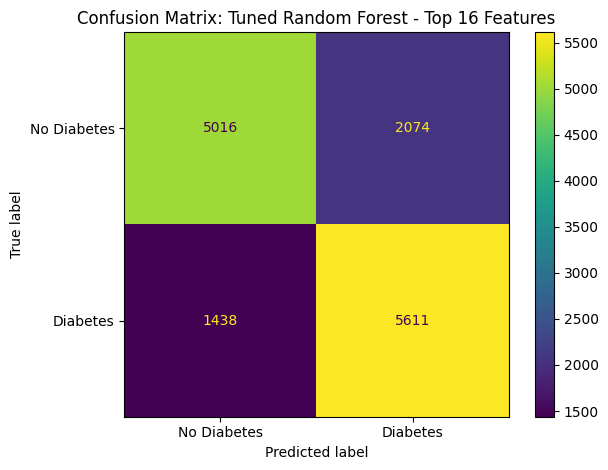

In [ ]:
# Top 16 features

rf_top_16, predictions_top_16, result_top_16 = (
    train_reduced_feature_model(
        feature_list=top_16_features,
        model_name="Tuned Random Forest - Top 16 Features"
    )
)

Tuned Random Forest - Top 12 Features
Number of features: 12
Training accuracy:  0.769880
Testing accuracy:   0.748639
Precision class 1:  0.726448
Recall class 1:     0.795290
F1-score class 1:   0.759312
Overfitting gap:    0.021241

Confusion matrix values:
True Negatives:  4979
False Positives: 2111
False Negatives: 1443
True Positives:  5606

Classification report:
              precision    recall  f1-score   support

           0   0.775304  0.702257  0.736975      7090
           1   0.726448  0.795290  0.759312      7049

    accuracy                       0.748639     14139
   macro avg   0.750876  0.748773  0.748143     14139
weighted avg   0.750947  0.748639  0.748111     14139



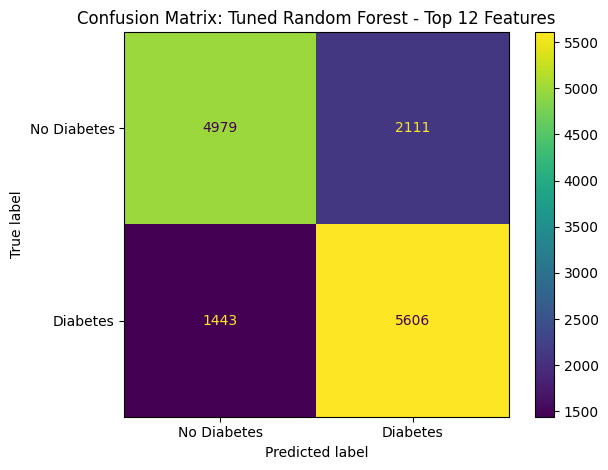

In [ ]:
# Top 12 features

rf_top_12, predictions_top_12, result_top_12 = (
    train_reduced_feature_model(
        feature_list=top_12_features,
        model_name="Tuned Random Forest - Top 12 Features"
    )
)

Tuned Random Forest - Top 8 Features
Number of features: 8
Training accuracy:  0.765583
Testing accuracy:   0.747083
Precision class 1:  0.725432
Recall class 1:     0.792737
F1-score class 1:   0.757592
Overfitting gap:    0.018500

Confusion matrix values:
True Negatives:  4975
False Positives: 2115
False Negatives: 1461
True Positives:  5588

Classification report:
              precision    recall  f1-score   support

           0   0.772996  0.701693  0.735620      7090
           1   0.725432  0.792737  0.757592      7049

    accuracy                       0.747083     14139
   macro avg   0.749214  0.747215  0.746606     14139
weighted avg   0.749283  0.747083  0.746574     14139



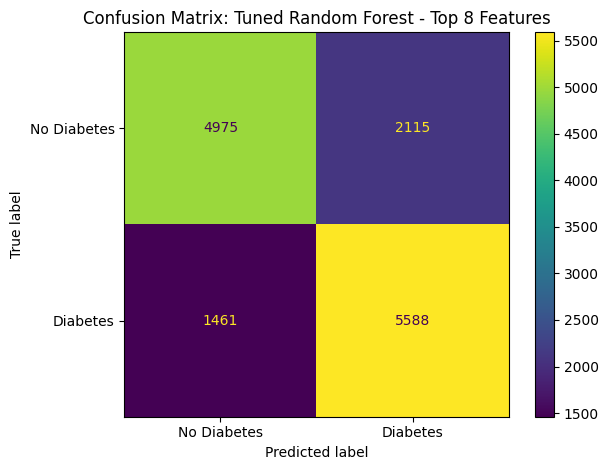

In [ ]:
# Top 8 features

rf_top_8, predictions_top_8, result_top_8 = (
    train_reduced_feature_model(
        feature_list=top_8_features,
        model_name="Tuned Random Forest - Top 8 Features"
    )
)

Tuned Random Forest - Top 4 Features
Number of features: 4
Training accuracy:  0.750889
Testing accuracy:   0.740788
Precision class 1:  0.719912
Recall class 1:     0.785785
F1-score class 1:   0.751407
Overfitting gap:    0.010101

Confusion matrix values:
True Negatives:  4935
False Positives: 2155
False Negatives: 1510
True Positives:  5539

Classification report:
              precision    recall  f1-score   support

           0   0.765710  0.696051  0.729221      7090
           1   0.719912  0.785785  0.751407      7049

    accuracy                       0.740788     14139
   macro avg   0.742811  0.740918  0.740314     14139
weighted avg   0.742877  0.740788  0.740282     14139



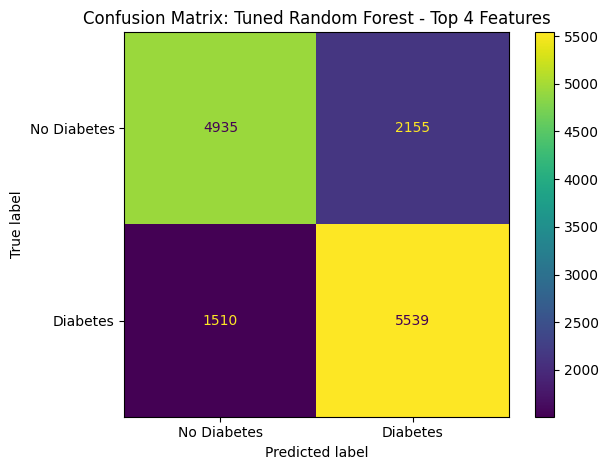

In [ ]:
# Top 4 features

rf_top_4, predictions_top_4, result_top_4 = (
    train_reduced_feature_model(
        feature_list=top_4_features,
        model_name="Tuned Random Forest - Top 4 Features"
    )
)

In [ ]:
# Calculate AUC

X_test_top_4 = X_test[top_4_features]

top_4_probabilities = rf_top_4.predict_proba(X_test_top_4)[:, 1]

top_4_auc = roc_auc_score(
    y_test,
    top_4_probabilities
)

print(f"Top 4 feature model AUC: {top_4_auc:.6f}")

Top 4 feature model AUC: 0.813054


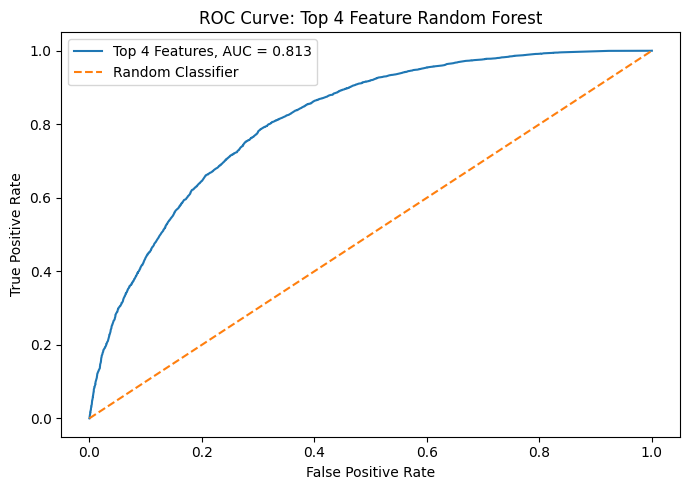

In [ ]:
# Plot ROC curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    top_4_probabilities
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Top 4 Features, AUC = {top_4_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve: Top 4 Feature Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Final results of our implementation

our_results = pd.DataFrame(experiment_results)

our_results = our_results[
    [
        "Model",
        "Feature Count",
        "Train Accuracy",
        "Test Accuracy",
        "Precision Class 1",
        "Recall Class 1",
        "F1 Class 1",
        "Overfitting Gap",
        "TN",
        "FP",
        "FN",
        "TP"
    ]
]

our_results = our_results.round(6)

display(our_results)

,Model,Feature Count,Train Accuracy,Test Accuracy,Precision Class 1,Recall Class 1,F1 Class 1,Overfitting Gap,TN,FP,FN,TP
0,Default Random Forest,21,0.995102,0.737110,0.717210,0.780394,0.747469,0.257992,4921,2169,1548,5501
1,Random Forest + Balanced Weight,21,0.995102,0.738383,0.719298,0.779401,0.748145,0.256719,4946,2144,1555,5494
2,Tuned Random Forest - All 21 Features,21,0.771100,0.752175,0.730584,0.796709,0.762215,0.018925,5019,2071,1433,5616
3,Tuned Random Forest - Top 16 Features,16,0.772267,0.751609,0.730124,0.795999,0.761640,0.020658,5016,2074,1438,5611
4,Tuned Random Forest - Top 12 Features,12,0.769880,0.748639,0.726448,0.795290,0.759312,0.021241,4979,2111,1443,5606
5,Tuned Random Forest - Top 8 Features,8,0.765583,0.747083,0.725432,0.792737,0.757592,0.018500,4975,2115,1461,5588
6,Tuned Random Forest - Top 4 Features,4,0.750889,0.740788,0.719912,0.785785,0.751407,0.010101,4935,2155,1510,5539
